In [1]:
import sys
sys.path.append("../src")

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from model import DyckTransformer
from data import generate_examples
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}

model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
model.load_state_dict(torch.load("../results/models/det_dyck_transformer.pt", map_location=device))
model.eval()

DyckTransformer(
  (embed): Embedding(7, 128)
  (pos): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (cls_head): Linear(in_features=128, out_features=2, bias=True)
  (token_head): Linear(in_features=128, out_features=6, bias=True)
)

In [2]:
def get_attention_weights(model, input_ids):
    attention_maps = []
    hooks = []
    
    # Build padding mask manually: True where PAD
    pad_mask = (input_ids == model.pad_idx)  # (B, T)

    def make_hook(layer_idx):
        def hook(module, input, output):
            with torch.no_grad():
                x = input[0]
                mha = module.self_attn
                B, T, D = x.shape
                H = mha.num_heads
                head_dim = D // H

                q, k, v = F.linear(x, mha.in_proj_weight, mha.in_proj_bias).chunk(3, dim=-1)
                q = q.view(B, T, H, head_dim).transpose(1, 2)  # (B, H, T, head_dim)
                k = k.view(B, T, H, head_dim).transpose(1, 2)
                scale = head_dim ** -0.5
                scores = q @ k.transpose(-2, -1) * scale  # (B, H, T, T)
                
                # Mask out padding keys
                if pad_mask is not None:
                    scores = scores.masked_fill(
                        pad_mask.unsqueeze(1).unsqueeze(2), float('-inf')
                    )
                
                attn = torch.softmax(scores, dim=-1)
                attention_maps.append(attn.detach().squeeze(0))  # (H, T, T)
        return hook

    for i, layer in enumerate(model.encoder.layers):
        h = layer.register_forward_hook(make_hook(i))
        hooks.append(h)

    with torch.no_grad():
        x = model.embed(input_ids)
        x = model.pos(x)
        for layer in model.encoder.layers:
            x = layer(x)

    for h in hooks:
        h.remove()

    return attention_maps

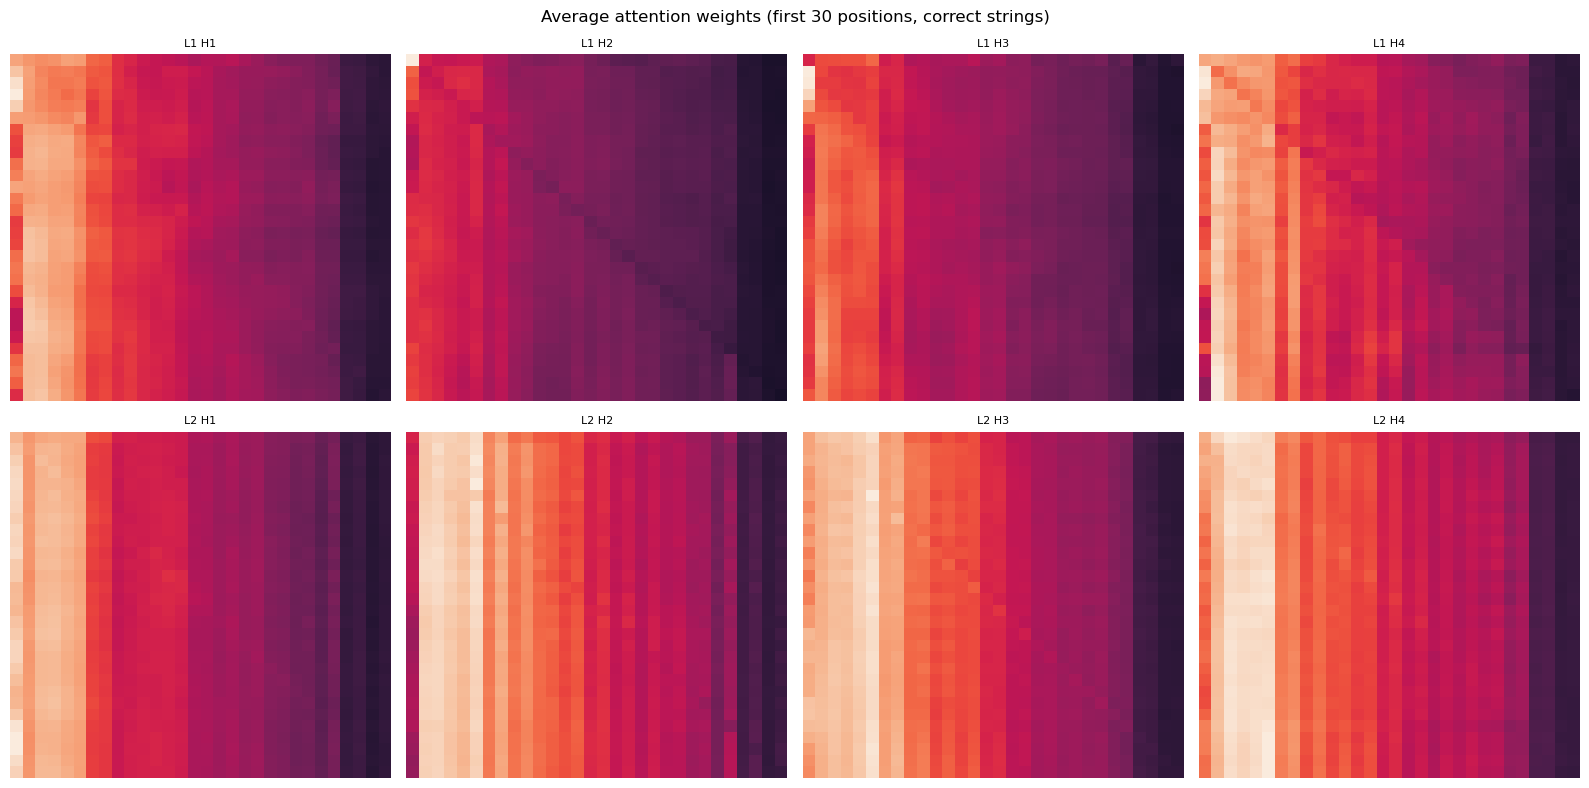

In [3]:
def tokens_to_ids(tokens, stoi):
    return torch.tensor([[stoi[t] for t in tokens]])

all_examples = generate_examples(500, max_depth=4, corrupt_prob=0.5, task="detection")
correct_samples = [(tokens, label) for tokens, label in all_examples if label == 1][:100]

n_layers = len(model.encoder.layers)
n_heads = 4
seq_len = 80

avg_attn = np.zeros((n_layers, n_heads, seq_len, seq_len))

for tokens, label in correct_samples:
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    for l, m in enumerate(maps):
        avg_attn[l] += m.numpy()

avg_attn /= len(correct_samples)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(16, 8))
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l][h]
        sns.heatmap(avg_attn[l, h, :30, :30], ax=ax, cbar=False, vmin=0, vmax=avg_attn[l, h, :30, :30].max())
        ax.set_title(f"L{l+1} H{h+1}", fontsize=8)
        ax.axis("off")
plt.suptitle("Average attention weights (first 30 positions, correct strings)")
plt.tight_layout()
plt.savefig("../results/figures/avg_attention_correct.png", dpi=150)
plt.show()

In [4]:
for l in range(n_layers):
    for h in range(n_heads):
        print(f"L{l+1}H{h+1} max={avg_attn[l,h,:30,:30].max():.4f} mean={avg_attn[l,h,:30,:30].mean():.4f}")

L1H1 max=0.0695 mean=0.0326
L1H2 max=0.1018 mean=0.0326
L1H3 max=0.0838 mean=0.0326
L1H4 max=0.0680 mean=0.0326
L2H1 max=0.0690 mean=0.0325
L2H2 max=0.0580 mean=0.0325
L2H3 max=0.0593 mean=0.0326
L2H4 max=0.0575 mean=0.0325


In [5]:
def get_matched_pairs(tokens):
    stack = []
    pairs = []
    for idx, tok in enumerate(tokens):
        if tok in ("(", "["):
            stack.append((tok, idx))
        elif tok == ")":
            if stack and stack[-1][0] == "(":
                _, open_idx = stack.pop()
                pairs.append((open_idx, idx))
        elif tok == "]":
            if stack and stack[-1][0] == "[":
                _, open_idx = stack.pop()
                pairs.append((open_idx, idx))
    return pairs

results = {l: {h: {"i_to_j": [], "j_to_i": []} for h in range(n_heads)} for l in range(n_layers)}

for tokens, label in correct_samples:
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    pairs = get_matched_pairs(tokens)
    for (i, j) in pairs:
        for l, m in enumerate(maps):
            for h in range(n_heads):
                results[l][h]["i_to_j"].append(m[h, i, j].item())
                results[l][h]["j_to_i"].append(m[h, j, i].item())

print(f"{'':10} {'α i→j mean':>12} {'α i→j std':>12} {'α j→i mean':>12} {'α j→i std':>12}")
for l in range(n_layers):
    for h in range(n_heads):
        d = results[l][h]
        print(f"L{l+1}H{h+1}      "
              f"{np.mean(d['i_to_j']):>12.4f} {np.std(d['i_to_j']):>12.4f} "
              f"{np.mean(d['j_to_i']):>12.4f} {np.std(d['j_to_i']):>12.4f}")

             α i→j mean    α i→j std   α j→i mean    α j→i std
L1H1            0.0413       0.0197       0.0420       0.0199
L1H2            0.0384       0.0192       0.0371       0.0197
L1H3            0.0419       0.0190       0.0388       0.0194
L1H4            0.0352       0.0184       0.0419       0.0205
L2H1            0.0409       0.0194       0.0425       0.0207
L2H2            0.0448       0.0230       0.0414       0.0203
L2H3            0.0421       0.0219       0.0408       0.0197
L2H4            0.0454       0.0228       0.0386       0.0198


In [6]:
results_corrected = {l: {h: [] for h in range(n_heads)} for l in range(n_layers)}

for tokens, label in correct_samples:
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    pairs = get_matched_pairs(tokens)
    real_len = sum(1 for t in tokens if t != "[PAD]")
    
    for (i, j) in pairs:
        for l, m in enumerate(maps):
            for h in range(n_heads):
                alpha_ij = m[h, i, j].item()
                # baseline: mean attention from i to ALL real tokens except j
                all_except_j = [m[h, i, k].item() for k in range(real_len) if k != j]
                baseline = np.mean(all_except_j)
                ratio = alpha_ij / (baseline + 1e-9)
                results_corrected[l][h].append(ratio)

print(f"{'':10} {'mean ratio':>12} {'std':>12}")
for l in range(n_layers):
    for h in range(n_heads):
        vals = results_corrected[l][h]
        print(f"L{l+1}H{h+1}      {np.mean(vals):>12.4f} {np.std(vals):>12.4f}")

             mean ratio          std
L1H1            0.9980       0.1014
L1H2            0.9222       0.0708
L1H3            1.0165       0.0847
L1H4            0.8383       0.0886
L2H1            0.9922       0.1083
L2H2            1.0865       0.1942
L2H3            1.0092       0.1117
L2H4            1.1105       0.2406


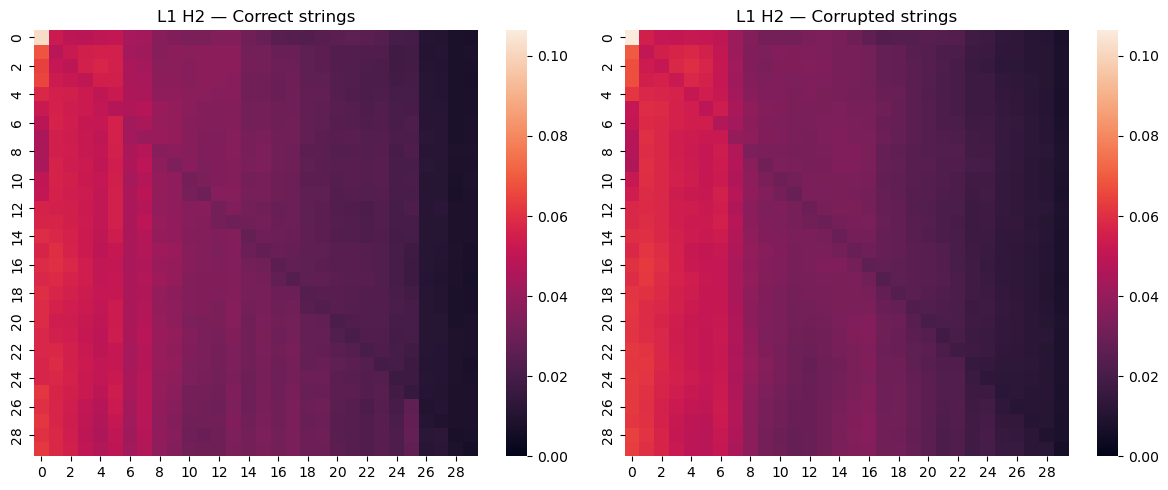

In [7]:
corrupted_samples = [(tokens, label) for tokens, label in all_examples if label == 0][:100]

avg_attn_err = np.zeros((n_layers, n_heads, seq_len, seq_len))
for tokens, label in corrupted_samples:
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    for l, m in enumerate(maps):
        avg_attn_err[l] += m.numpy()
avg_attn_err /= len(corrupted_samples)

l_star, h_star = 0, 1  # head with highest max from the print cell

vmax = max(avg_attn[l_star, h_star, :30, :30].max(), avg_attn_err[l_star, h_star, :30, :30].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, attn, title in zip(axes,
                            [avg_attn[l_star, h_star], avg_attn_err[l_star, h_star]],
                            ["Correct strings", "Corrupted strings"]):
    sns.heatmap(attn[:30, :30], ax=ax, vmin=0, vmax=vmax)
    ax.set_title(f"L{l_star+1} H{h_star+1} — {title}")
plt.tight_layout()
plt.savefig("../results/figures/attention_correct_vs_corrupted.png", dpi=150)
plt.show()

Aligned over 114 sequences


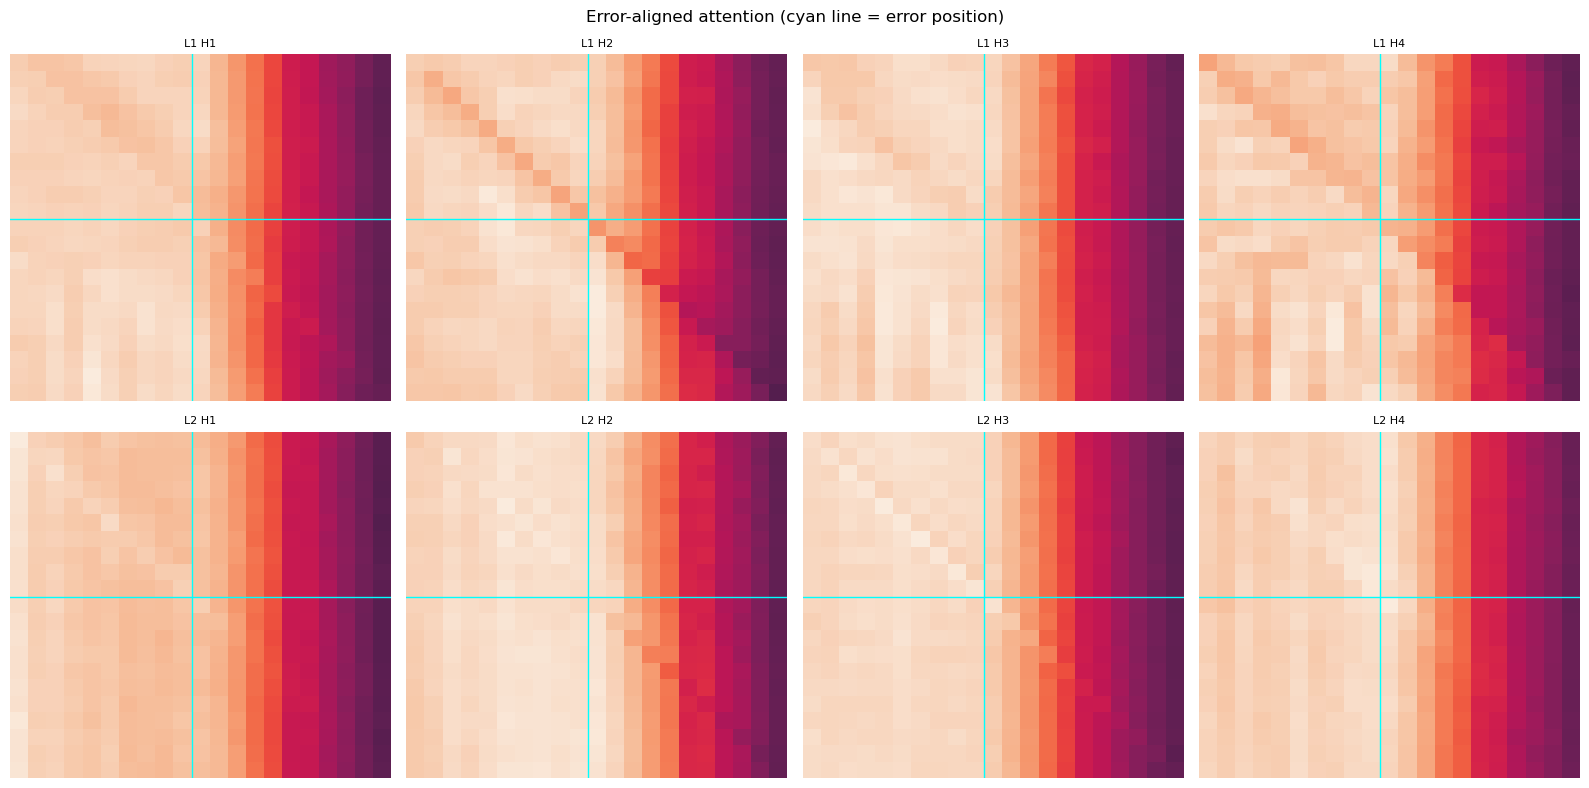

In [8]:
corrupted_examples = generate_examples(500, max_depth=4, corrupt_prob=1.0, task="both")
# corrupt_prob=1.0 means all are corrupted, and we get edit_labels

# Find error position: first token that is not "OK"
EDIT_LABELS = ["OK", "DELETE", "REPLACE_OPEN", "REPLACE_CLOSE", "INSERT_BEFORE", "INSERT_AFTER"]
label2id = {l: i for i, l in enumerate(EDIT_LABELS)}

def find_error_pos(edit_labels):
    for i, l in enumerate(edit_labels):
        if l != "OK":
            return i
    return None

# Collect attention maps aligned to error position
# For each sample, shift attention so error is always at position k (e.g. k=10)
k = 10  # anchor error position
window = 10  # look +/- 10 tokens around the error
aligned_attn = np.zeros((n_layers, n_heads, 2*window+1, 2*window+1))
count = 0

for tokens, binary_label, edit_labels in corrupted_examples[:200]:
    err_pos = find_error_pos(edit_labels)
    if err_pos is None:
        continue
    if err_pos < window or err_pos + window >= len(tokens):
        continue  # skip if error too close to edge
    
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    
    for l, m in enumerate(maps):
        # Extract window around error position
        lo, hi = err_pos - window, err_pos + window + 1
        aligned_attn[l] += m[:, lo:hi, lo:hi].numpy()
    count += 1

aligned_attn /= count
print(f"Aligned over {count} sequences")

# Plot: error-aligned attention for best head
fig, axes = plt.subplots(n_layers, n_heads, figsize=(16, 8))
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l][h]
        sns.heatmap(aligned_attn[l, h], ax=ax, cbar=False,
                    vmin=0, vmax=aligned_attn[l, h].max())
        ax.set_title(f"L{l+1} H{h+1}", fontsize=8)
        ax.axvline(x=window, color='cyan', linewidth=1)   # error column
        ax.axhline(y=window, color='cyan', linewidth=1)   # error row
        ax.axis("off")
plt.suptitle("Error-aligned attention (cyan line = error position)")
plt.tight_layout()
plt.savefig("../results/figures/attention_error_aligned.png", dpi=150)
plt.show()

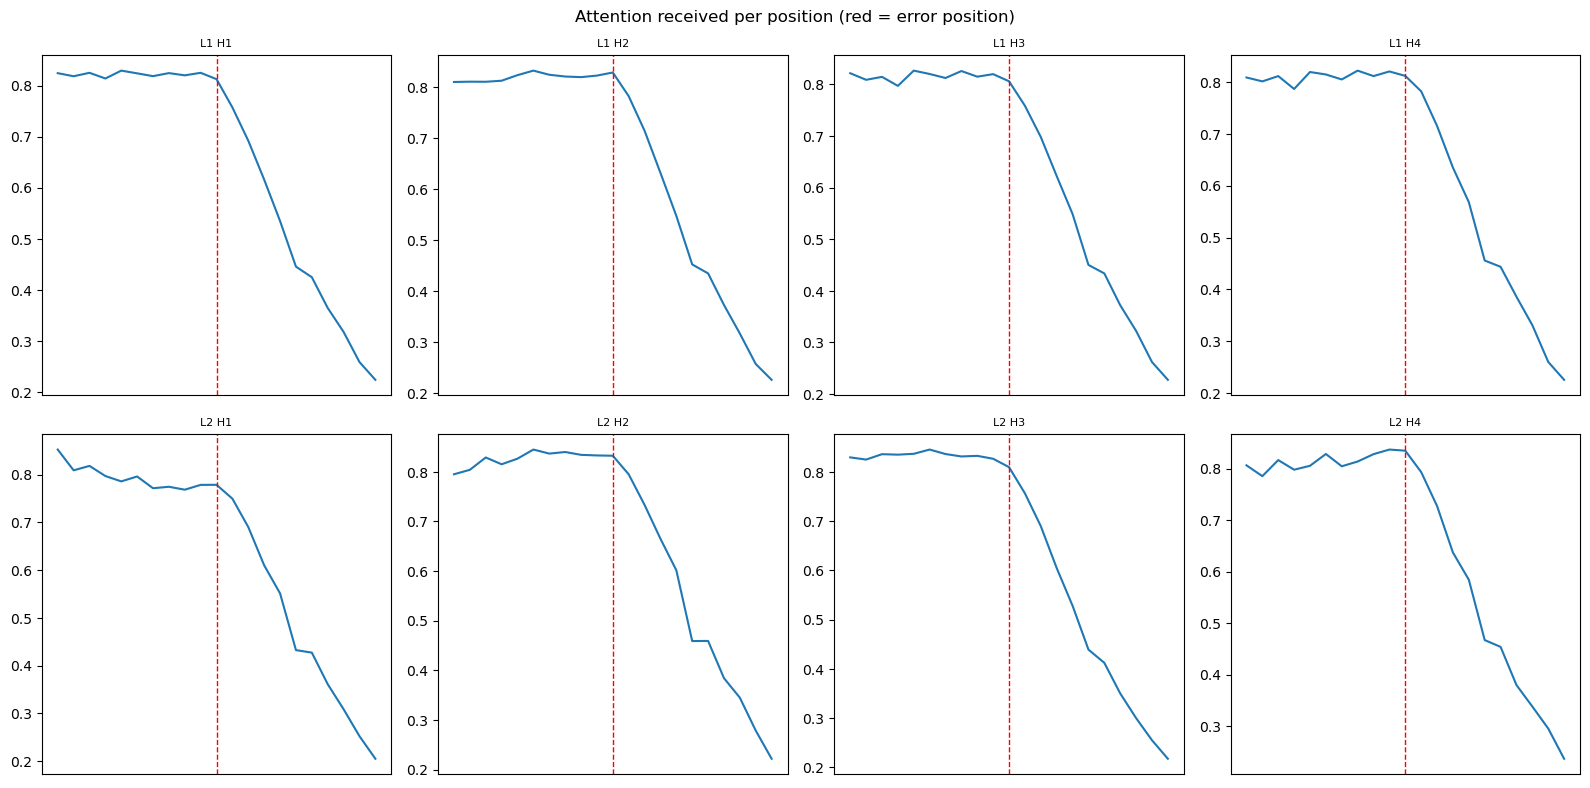

In [9]:
# For each position relative to error, how much attention does it receive on average?
# Sum over query positions for each key position
attention_to_pos = aligned_attn.sum(axis=2)  # (n_layers, n_heads, 2*window+1)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(16, 8))
x = np.arange(-window, window+1)
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l][h]
        ax.plot(x, attention_to_pos[l, h])
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"L{l+1} H{h+1}", fontsize=8)
        ax.set_xticks([])
plt.suptitle("Attention received per position (red = error position)")
plt.tight_layout()
plt.savefig("../results/figures/attention_by_error_offset.png", dpi=150)
plt.show()

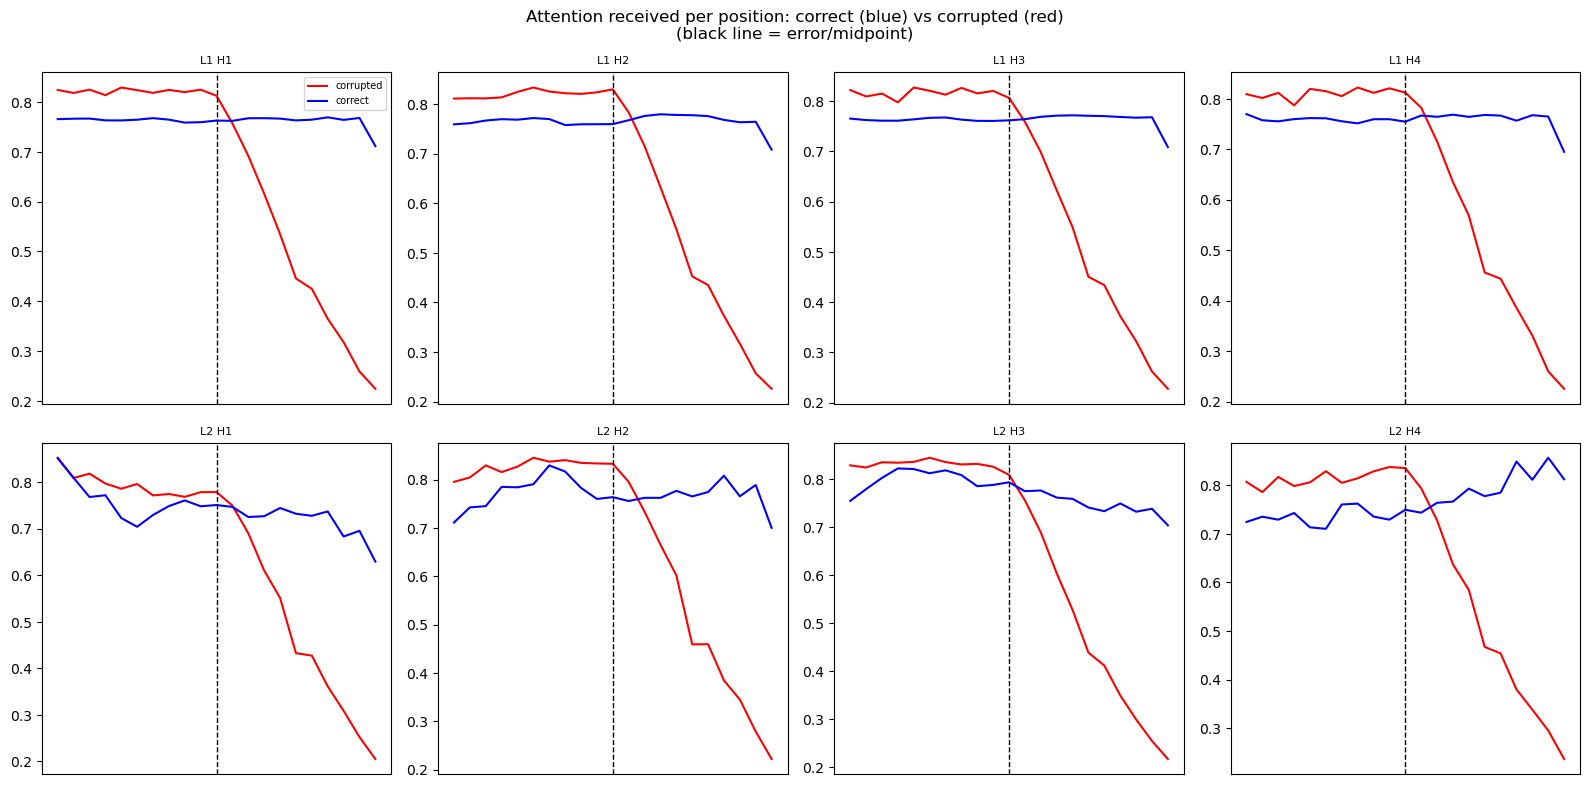

In [10]:
# Same plot but for correct sequences, aligned to the MIDDLE of the sequence
# (since there's no error position, we use the midpoint as anchor)

aligned_attn_correct = np.zeros((n_layers, n_heads, 2*window+1, 2*window+1))
count_correct = 0

for tokens, label in correct_samples:
    mid = len([t for t in tokens if t != "[PAD]"]) // 2  # midpoint of real tokens
    if mid < window or mid + window >= len(tokens):
        continue
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    for l, m in enumerate(maps):
        lo, hi = mid - window, mid + window + 1
        aligned_attn_correct[l] += m[:, lo:hi, lo:hi].numpy()
    count_correct += 1

aligned_attn_correct /= count_correct

# Line plot: attention received per position relative to midpoint
attention_to_pos_correct = aligned_attn_correct.sum(axis=2)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(16, 8))
x = np.arange(-window, window+1)
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l][h]
        ax.plot(x, attention_to_pos[l, h], label="corrupted", color="red")
        ax.plot(x, attention_to_pos_correct[l, h], label="correct", color="blue")
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f"L{l+1} H{h+1}", fontsize=8)
        ax.set_xticks([])
axes[0][0].legend(fontsize=7)
plt.suptitle("Attention received per position: correct (blue) vs corrupted (red)\n(black line = error/midpoint)")
plt.tight_layout()
plt.savefig("../results/figures/attention_correct_vs_corrupted_line.png", dpi=150)
plt.show()

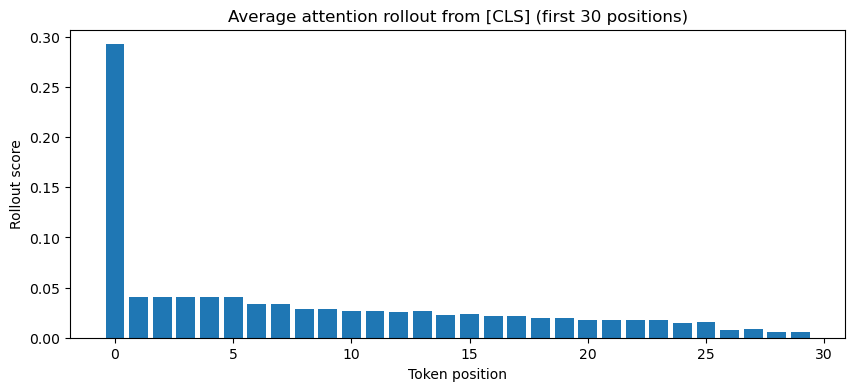

Tokens: ['[CLS]', '(', '[', '(', '(', ')', '(', ')', ')', '[', ']', '(', '(', ')', '(', ')', ')', '(', '(', ')', '(', ')', '(', ')', ')', ']', ')', '[SEP]']
Rollout: ['0.277', '0.027', '0.026', '0.027', '0.027', '0.027', '0.027', '0.027', '0.027', '0.026', '0.026', '0.026', '0.026', '0.027', '0.027', '0.027', '0.027', '0.027', '0.026', '0.027', '0.027', '0.027', '0.027', '0.027', '0.027', '0.026', '0.027', '0.029']


In [11]:
def attention_rollout(maps):
    """
    maps: list of (n_heads, seq_len, seq_len), one per layer
    Returns: (seq_len,) array — how much each token contributes to CLS
    """
    result = np.eye(maps[0].shape[-1])  # start with identity
    for m in maps:
        # average over heads
        A = m.numpy().mean(axis=0)  # (seq_len, seq_len)
        # add residual connection
        A_hat = 0.5 * A + 0.5 * np.eye(A.shape[0])
        # normalize rows
        A_hat = A_hat / A_hat.sum(axis=-1, keepdims=True)
        result = A_hat @ result
    # return CLS row (position 0)
    return result[0]

# Compute rollout on 100 correct sequences
rollout_scores = np.zeros(80)
count = 0

for tokens, label in correct_samples[:100]:
    ids = tokens_to_ids(tokens, stoi)
    maps = get_attention_weights(model, ids)
    rollout = attention_rollout(maps)
    real_len = sum(1 for t in tokens if t != "[PAD]")
    rollout_scores[:real_len] += rollout[:real_len]
    count += 1

rollout_scores /= count

# Plot
plt.figure(figsize=(10, 4))
plt.bar(range(30), rollout_scores[:30])
plt.xlabel("Token position")
plt.ylabel("Rollout score")
plt.title("Average attention rollout from [CLS] (first 30 positions)")
plt.savefig("../results/figures/attention_rollout.png", dpi=150)
plt.show()

# Also show for a single example
tokens, label = correct_samples[0]
ids = tokens_to_ids(tokens, stoi)
maps = get_attention_weights(model, ids)
rollout = attention_rollout(maps)
real_len = sum(1 for t in tokens if t != "[PAD]")


print("Tokens:", tokens[:real_len])
print("Rollout:", [f"{v:.3f}" for v in rollout[:real_len]])

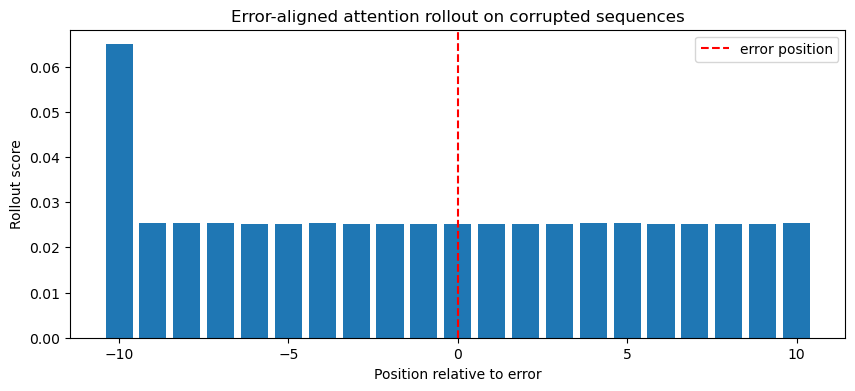

In [13]:
# Rollout aligned to error position on corrupted sequences
import random
from data import generate_clean, E1_missing_closer, E2_spurious_opener, E3_type_mismatch, E4_premature_close

parenthesis = {"(": ")", "[": "]"}
error_fns = [E1_missing_closer, E2_spurious_opener, E3_type_mismatch, E4_premature_close]

window = 10
aligned_rollout = np.zeros(2 * window + 1)
count = 0

for _ in range(500):
    clean = generate_clean(parenthesis, min_len=6, max_len=38, max_depth=4)
    fn = random.choice(error_fns)
    corrupted_seq, edit_info = fn(clean.copy(), parenthesis)
    if edit_info is None:
        continue

    if edit_info[0] == "DELETE":
        err_pos = edit_info[1] + 1
    elif edit_info[0] in ("REPLACE", "INSERT"):
        err_pos = edit_info[1] + 1

    corrupted_tokens = ["[CLS]"] + corrupted_seq + ["[SEP]"]
    while len(corrupted_tokens) < 80:
        corrupted_tokens.append("[PAD]")
    corrupted_tokens = corrupted_tokens[:80]

    if err_pos < window or err_pos + window >= sum(1 for t in corrupted_tokens if t != "[PAD]"):
        continue

    ids = tokens_to_ids(corrupted_tokens, stoi)
    maps = get_attention_weights(model, ids)
    rollout = attention_rollout(maps)

    aligned_rollout += rollout[err_pos - window: err_pos + window + 1]
    count += 1

aligned_rollout /= count

plt.figure(figsize=(10, 4))
x = np.arange(-window, window + 1)
plt.bar(x, aligned_rollout)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label="error position")
plt.xlabel("Position relative to error")
plt.ylabel("Rollout score")
plt.title("Error-aligned attention rollout on corrupted sequences")
plt.legend()
plt.savefig("../results/figures/attention_rollout_aligned.png", dpi=150)
plt.show()